# Phase sequence 기반 count 튜닝 실험

모델이 뱉은 `ready/down/up` phase sequence를 기준으로 **smoothing + FSM count rule**을 바꿔가며 반복 횟수 오차를 비교하는 notebook입니다.

튜닝 축:

- `smooth_window`: phase 깜빡임 억제 강도
- `smooth_mode`: `causal`(실시간) / `centered`(offline)
- `min_target_len`: count 대상 phase(`up`) 최소 지속 프레임
- `require_prior`, `min_prior_len`: `up` 전에 `down`을 충분히 봐야 하는지
- `min_rep_gap`: count 사이 최소 간격
- `count_on`: `up` 구간 종료 시점 vs `min_target_len` 도달 즉시
- confidence/margin hold, probability EMA

기본 입력은 `phase_experiments/**/raw_phase_predictions.csv` 중 가장 최근 파일입니다.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from itertools import product
from pathlib import Path
from typing import Dict, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
try:
    from IPython.display import display, Markdown
except Exception:  # fallback for plain Python execution outside notebooks
    class Markdown(str):
        pass
    def display(obj):
        print(obj)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

REPO = Path.cwd()
PHASE_NAMES = ["ready", "down", "up"]
PHASE_TO_ID = {name: i for i, name in enumerate(PHASE_NAMES)}
ID_TO_PHASE = {i: name for name, i in PHASE_TO_ID.items()}
PHASE_COLORS = ["#9ca3af", "#2563eb", "#22c55e"]
PHASE_CMAP = ListedColormap(PHASE_COLORS)

print("repo:", REPO)

repo: C:\Users\kojy1\PycharmProjects\capstone


## 1) 입력 artifact 선택

`raw_phase_predictions.csv`는 모델 phase probability / raw phase / offline-smoothed phase를 담고 있습니다.
이 notebook은 valid inference frame 사이를 forward-fill해서 full per-frame phase sequence를 재구성합니다.

In [2]:
# None이면 자동 탐색.
PRED_PATH: Optional[Path | str] = None
LABEL_PATH: Optional[Path | str] = None

# "auto"면 prediction path에 bar_direction 문자열이 있으면 bar_direction, 아니면 as_labeled.
PHASE_LABEL_SCHEME = "auto"  # "auto" | "as_labeled" | "bar_direction"

# 빠르게 보려면 정수 지정. 전체는 None.
MAX_VIDEOS: Optional[int] = None

prediction_candidates = sorted(
    REPO.glob("phase_experiments/**/raw_phase_predictions.csv"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not prediction_candidates:
    raise FileNotFoundError("phase_experiments/**/raw_phase_predictions.csv 를 찾지 못했습니다.")

PRED_PATH = prediction_candidates[0] if PRED_PATH is None else Path(PRED_PATH)

if LABEL_PATH is None:
    label_candidates = sorted(REPO.glob("data/**/labels/labels.csv")) + sorted(REPO.glob("data/**/labels.csv"))
    if not label_candidates:
        raise FileNotFoundError("data/**/labels/labels.csv 를 찾지 못했습니다.")
    LABEL_PATH = label_candidates[0]
else:
    LABEL_PATH = Path(LABEL_PATH)

if PHASE_LABEL_SCHEME == "auto":
    text = str(PRED_PATH).replace("\\", "/").lower()
    PHASE_LABEL_SCHEME_RESOLVED = "bar_direction" if "bar_direction" in text or "label_bar_direction" in text else "as_labeled"
else:
    PHASE_LABEL_SCHEME_RESOLVED = PHASE_LABEL_SCHEME

print("prediction candidates:", len(prediction_candidates))
print("PRED_PATH:", PRED_PATH)
print("LABEL_PATH:", LABEL_PATH)
print("PHASE_LABEL_SCHEME_RESOLVED:", PHASE_LABEL_SCHEME_RESOLVED)

prediction candidates: 42
PRED_PATH: C:\Users\kojy1\PycharmProjects\capstone\phase_experiments\barbell_yolo_world\joint_fusion_exercise_label\diagnostics\full\same_run_joint_fusion_exercise_label\mediapipe_barbell_mediapipe33_barbell34_wrists_jall_mlp_h128_c16_pw_2.0_ts2_do03_aug1_head_exercise_attn_cond_ground_truth_exercise_label_label_bar_direction_edge_wrists\raw_phase_predictions.csv
LABEL_PATH: C:\Users\kojy1\PycharmProjects\capstone\data\측면\data\labels\labels.csv
PHASE_LABEL_SCHEME_RESOLVED: bar_direction


In [3]:
def load_predictions(path: Path | str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"type", "name", "frame_idx", "pred_phase_raw", "gt_phase"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"raw prediction csv missing columns: {sorted(missing)}")
    df = df.copy()
    df["frame_idx"] = df["frame_idx"].astype(int)
    df["pred_phase_raw"] = df["pred_phase_raw"].astype(int)
    if "pred_phase_offline_smooth" in df.columns:
        df["pred_phase_offline_smooth"] = df["pred_phase_offline_smooth"].astype(int)
    for col in ["phase_prob_ready", "phase_prob_down", "phase_prob_up"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values(["type", "name", "frame_idx"]).reset_index(drop=True)


def is_incomplete_value(value) -> bool:
    if pd.isna(value):
        return False
    return str(value).strip().lower() in {"x", "incomplete", "미완", "미완료", "중단"}


def parse_reps_from_row(row: pd.Series, max_reps: int = 120) -> List[Tuple[int, int, int]]:
    reps: List[Tuple[int, int, int]] = []
    for i in range(max_reps):
        s_col, b_col, f_col = f"L{3 * i + 1}", f"L{3 * i + 2}", f"L{3 * i + 3}"
        if s_col not in row.index:
            break
        vals = [row.get(s_col), row.get(b_col), row.get(f_col)]
        if all(pd.isna(v) for v in vals):
            break
        if any(is_incomplete_value(v) for v in vals) or any(pd.isna(v) for v in vals):
            break
        try:
            s, b, f = (int(float(v)) for v in vals)
        except (TypeError, ValueError):
            break
        if f > s:
            reps.append((s, b, f))
    return reps


def load_labels(path: Path | str) -> Dict[Tuple[str, str], Dict[str, object]]:
    labels_df = pd.read_csv(path)
    labels_df.columns = [str(c).strip() for c in labels_df.columns]
    labels_df = labels_df.loc[:, ~labels_df.columns.str.startswith("Unnamed")]
    out: Dict[Tuple[str, str], Dict[str, object]] = {}
    for _, row in labels_df.iterrows():
        typ = str(row["type"]).strip()
        name = str(row["name"]).strip()
        reps = parse_reps_from_row(row)
        count_col = row.get("count")
        count = int(count_col) if pd.notna(count_col) else len(reps)
        out[(typ, name)] = {"count_col": count, "reps": reps, "rep_count": len(reps)}
    return out


def make_gt_phase(T: int, reps: Sequence[Tuple[int, int, int]], exercise: str, scheme: str) -> np.ndarray:
    phase = np.zeros(int(T), dtype=np.int64)
    first_phase, second_phase = PHASE_TO_ID["down"], PHASE_TO_ID["up"]
    if scheme == "bar_direction" and str(exercise).strip().lower() == "deadlift":
        first_phase, second_phase = PHASE_TO_ID["up"], PHASE_TO_ID["down"]
    for s, b, f in reps:
        s = max(0, min(int(s), T - 1))
        b = max(0, min(int(b), T - 1))
        f = max(0, min(int(f), T - 1))
        if b > s:
            phase[s:b] = first_phase
        if f > b:
            phase[b:f] = second_phase
    return phase


pred_df = load_predictions(PRED_PATH)
labels = load_labels(LABEL_PATH)

if MAX_VIDEOS is not None:
    keep = pred_df[["type", "name"]].drop_duplicates().head(MAX_VIDEOS)
    pred_df = pred_df.merge(keep, on=["type", "name"], how="inner")

print("prediction rows:", len(pred_df))
print("videos:", pred_df[["type", "name"]].drop_duplicates().shape[0])
print("labels:", len(labels))
display(pred_df.head())

prediction rows: 11700
videos: 42
labels: 210


,type,name,split,frame_idx,clip_len,stride,phase_conditioning,exercise_id_source,conditioning_exercise_id,gt_phase,gt_phase_name,pred_phase_raw,pred_phase_raw_name,pred_phase_offline_smooth,pred_phase_offline_smooth_name,phase_prob_ready,phase_prob_down,phase_prob_up,boundary_distance,action_pred,action_prob_squat,action_prob_benchpress,action_prob_deadlift
0,benchpress,bench press_1.mp4,val,15,16,2,ground_truth_exercise_label,ground_truth_label,1,1,down,1,down,1,down,0.045391,0.954072,0.000536,14.0,benchpress,0.000127,0.999873,7.422996e-08
1,benchpress,bench press_1.mp4,val,17,16,2,ground_truth_exercise_label,ground_truth_label,1,1,down,1,down,1,down,0.043776,0.955676,0.000548,12.0,benchpress,0.000127,0.999873,7.422996e-08
2,benchpress,bench press_1.mp4,val,19,16,2,ground_truth_exercise_label,ground_truth_label,1,1,down,1,down,1,down,0.031772,0.967456,0.000772,10.0,benchpress,0.000127,0.999873,7.422996e-08
3,benchpress,bench press_1.mp4,val,21,16,2,ground_truth_exercise_label,ground_truth_label,1,1,down,1,down,1,down,0.025868,0.971458,0.002674,8.0,benchpress,0.000127,0.999873,7.422996e-08
4,benchpress,bench press_1.mp4,val,23,16,2,ground_truth_exercise_label,ground_truth_label,1,1,down,1,down,1,down,0.018611,0.976140,0.005249,6.0,benchpress,0.000127,0.999873,7.422996e-08


## 2) Phase sequence 재구성 + smoothing

재구성 규칙:

1. valid frame의 `pred_phase_raw`를 읽음
2. valid frame 사이 invalid frame은 직전 valid phase로 forward-fill
3. 첫 valid frame 전은 `ready`

Smoothing:

- `centered`: 앞/뒤 frame을 같이 보는 offline majority vote
- `causal`: 최근 window만 보는 realtime majority vote

In [4]:
def reconstruct_full_sequence(group: pd.DataFrame, phase_col: str = "pred_phase_raw") -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    g = group.sort_values("frame_idx")
    valid_idx = g["frame_idx"].astype(int).to_numpy()
    if len(valid_idx) == 0:
        return np.zeros(0, dtype=np.int64), np.zeros((0, 3), dtype=float), valid_idx

    T = int(valid_idx.max()) + 1
    seq = np.zeros(T, dtype=np.int64) + PHASE_TO_ID["ready"]
    vals = g[phase_col].astype(int).to_numpy()

    prob_cols = ["phase_prob_ready", "phase_prob_down", "phase_prob_up"]
    has_probs = all(c in g.columns for c in prob_cols)
    probs = np.zeros((T, 3), dtype=float)
    probs[:, PHASE_TO_ID["ready"]] = 1.0
    prob_vals = g[prob_cols].fillna(0.0).to_numpy(dtype=float) if has_probs else None

    for k, start in enumerate(valid_idx):
        end = int(valid_idx[k + 1]) if k + 1 < len(valid_idx) else T
        seq[start:end] = vals[k]
        if prob_vals is not None:
            probs[start:end] = prob_vals[k]
    return seq, probs, valid_idx


def majority_smooth(seq: Sequence[int], window: int = 5, mode: str = "causal", tie_break: str = "latest") -> np.ndarray:
    seq = np.asarray(seq, dtype=np.int64)
    if window <= 1 or len(seq) == 0:
        return seq.copy()
    out = np.zeros_like(seq)
    h = window // 2
    for i in range(len(seq)):
        if mode == "centered":
            lo, hi = max(0, i - h), min(len(seq), i + h + 1)
        elif mode == "causal":
            lo, hi = max(0, i - window + 1), i + 1
        else:
            raise ValueError(f"unknown smoothing mode: {mode}")
        w = seq[lo:hi]
        counts = np.bincount(w, minlength=len(PHASE_NAMES))
        candidates = np.flatnonzero(counts == counts.max())
        if tie_break == "smallest":
            out[i] = int(candidates[0])
        elif tie_break == "latest":
            out[i] = max(candidates, key=lambda c: np.where(w == c)[0][-1])
        elif tie_break == "current":
            out[i] = int(seq[i]) if seq[i] in candidates else int(candidates[0])
        else:
            raise ValueError(f"unknown tie_break: {tie_break}")
    return out


def probs_to_phase_ids(
    probs: np.ndarray,
    method: str = "argmax",
    ema_alpha: float = 0.35,
    confidence_min: float = 0.0,
    margin_min: float = 0.0,
    hold_low_confidence: bool = True,
    initial_phase: int = PHASE_TO_ID["ready"],
) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    if len(probs) == 0:
        return np.zeros(0, dtype=np.int64)

    if method == "argmax":
        smooth_probs = probs
    elif method == "ema":
        alpha = min(max(float(ema_alpha), 0.0), 1.0)
        smooth_probs = np.zeros_like(probs)
        state = probs[0].copy()
        smooth_probs[0] = state
        for i in range(1, len(probs)):
            state = (1.0 - alpha) * state + alpha * probs[i]
            smooth_probs[i] = state
    else:
        raise ValueError(f"unknown prob method: {method}")

    out = np.zeros(len(smooth_probs), dtype=np.int64)
    prev = int(initial_phase)
    for i, p in enumerate(smooth_probs):
        order = np.argsort(p)[::-1]
        top1, top2 = int(order[0]), int(order[1])
        conf = float(p[top1])
        margin = float(p[top1] - p[top2])
        ambiguous = conf < confidence_min or margin < margin_min
        if hold_low_confidence and ambiguous:
            out[i] = prev
        else:
            out[i] = top1
            prev = top1
    return out

## 3) Count FSM

현재 코드와 가장 비슷한 count 조건:

```text
target_phase = up
min_target_len = 3
require_prior = False
count_on = segment_end
count_terminal_segment = False
```

여기에 `require_prior=True`, `min_prior_len`, `min_rep_gap`, `count_on='min_len_reached'` 등을 실험합니다.

In [ ]:
@dataclass(frozen=True)
class PhasePrepConfig:
    prob_method: str = "raw"  # "raw" | "argmax" | "ema"
    ema_alpha: float = 0.35
    confidence_min: float = 0.0
    margin_min: float = 0.0
    hold_low_confidence: bool = True
    smooth_window: int = 5
    smooth_window_by_exercise: Optional[Mapping[str, int]] = None
    smooth_mode: str = "causal"  # "causal" | "centered"
    tie_break: str = "latest"


@dataclass(frozen=True)
class CountConfig:
    target_phase: str = "up"
    prior_phase: str = "down"
    require_prior: bool = False
    prior_must_be_adjacent: bool = False
    min_target_len: int = 3
    min_prior_len: int = 1
    min_rep_gap: int = 0
    count_on: str = "segment_end"  # "segment_end" | "min_len_reached"
    count_terminal_segment: bool = False
    target_phase_by_exercise: Optional[Mapping[str, str]] = None
    prior_phase_by_exercise: Optional[Mapping[str, str]] = None
    require_prior_by_exercise: Optional[Mapping[str, bool]] = None
    prior_must_be_adjacent_by_exercise: Optional[Mapping[str, bool]] = None
    min_target_len_by_exercise: Optional[Mapping[str, int]] = None
    min_prior_len_by_exercise: Optional[Mapping[str, int]] = None
    min_rep_gap_by_exercise: Optional[Mapping[str, int]] = None
    count_on_by_exercise: Optional[Mapping[str, str]] = None


def contiguous_segments(seq: Sequence[int]) -> List[Tuple[int, int, int]]:
    seq = np.asarray(seq, dtype=np.int64)
    if len(seq) == 0:
        return []
    out: List[Tuple[int, int, int]] = []
    start = 0
    current = int(seq[0])
    for i in range(1, len(seq)):
        if int(seq[i]) != current:
            out.append((start, i, current))
            start = i
            current = int(seq[i])
    out.append((start, len(seq), current))
    return out


def _value_for_exercise(default, mapping: Optional[Mapping[str, object]], exercise: Optional[str]):
    if not mapping or exercise is None:
        return default
    if exercise in mapping:
        return mapping[exercise]
    exercise_key = str(exercise).strip().lower()
    if exercise_key in mapping:
        return mapping[exercise_key]
    return default


def _phase_for_exercise(default: str, mapping: Optional[Mapping[str, str]], exercise: str) -> int:
    name = _value_for_exercise(default, mapping, exercise)
    return PHASE_TO_ID[str(name)]


def count_phase_sequence(seq: Sequence[int], exercise: str, cfg: CountConfig) -> Dict[str, object]:
    seq = np.asarray(seq, dtype=np.int64)
    segs = contiguous_segments(seq)
    target = _phase_for_exercise(cfg.target_phase, cfg.target_phase_by_exercise, exercise)
    prior = _phase_for_exercise(cfg.prior_phase, cfg.prior_phase_by_exercise, exercise)

    require_prior = bool(_value_for_exercise(cfg.require_prior, cfg.require_prior_by_exercise, exercise))
    prior_must_be_adjacent = bool(
        _value_for_exercise(cfg.prior_must_be_adjacent, cfg.prior_must_be_adjacent_by_exercise, exercise)
    )
    min_target_len = int(_value_for_exercise(cfg.min_target_len, cfg.min_target_len_by_exercise, exercise))
    min_prior_len = int(_value_for_exercise(cfg.min_prior_len, cfg.min_prior_len_by_exercise, exercise))
    min_rep_gap = int(_value_for_exercise(cfg.min_rep_gap, cfg.min_rep_gap_by_exercise, exercise))
    count_on = str(_value_for_exercise(cfg.count_on, cfg.count_on_by_exercise, exercise))

    count = 0
    events: List[Dict[str, object]] = []
    seen_prior_ok = False
    last_count_frame = -10**9
    prev_seg: Optional[Tuple[int, int, int]] = None

    for start, end, phase_id in segs:
        length = end - start

        if phase_id == prior and length >= min_prior_len:
            seen_prior_ok = True

        if phase_id == target:
            target_ok = length >= min_target_len
            if require_prior:
                if prior_must_be_adjacent:
                    prior_ok = prev_seg is not None and prev_seg[2] == prior and (prev_seg[1] - prev_seg[0]) >= min_prior_len
                else:
                    prior_ok = seen_prior_ok
            else:
                prior_ok = True

            terminal = end == len(seq)
            if count_on == "segment_end":
                count_frame = end
                terminal_ok = cfg.count_terminal_segment or not terminal
            elif count_on == "min_len_reached":
                count_frame = start + min_target_len - 1
                terminal_ok = True
            else:
                raise ValueError(f"unknown count_on: {count_on}")

            gap_ok = (count_frame - last_count_frame) >= min_rep_gap
            if target_ok and prior_ok and terminal_ok and gap_ok:
                count += 1
                last_count_frame = int(count_frame)
                events.append(
                    {
                        "count": count,
                        "frame": int(min(count_frame, max(len(seq) - 1, 0))),
                        "raw_count_frame": int(count_frame),
                        "segment_start": int(start),
                        "segment_end": int(end),
                        "phase": ID_TO_PHASE[target],
                        "segment_len": int(length),
                        "prior_ok": bool(prior_ok),
                        "min_target_len": int(min_target_len),
                        "min_prior_len": int(min_prior_len),
                        "min_rep_gap": int(min_rep_gap),
                        "count_on": count_on,
                    }
                )
                seen_prior_ok = False

        prev_seg = (start, end, phase_id)

    return {"count": int(count), "events": events, "segments": segs}


def prepare_phase_sequence(
    raw_seq: np.ndarray,
    probs: np.ndarray,
    cfg: PhasePrepConfig,
    exercise: Optional[str] = None,
) -> np.ndarray:
    if cfg.prob_method == "raw":
        base = np.asarray(raw_seq, dtype=np.int64)
    elif cfg.prob_method in {"argmax", "ema"}:
        base = probs_to_phase_ids(
            probs,
            method=cfg.prob_method,
            ema_alpha=cfg.ema_alpha,
            confidence_min=cfg.confidence_min,
            margin_min=cfg.margin_min,
            hold_low_confidence=cfg.hold_low_confidence,
        )
    else:
        raise ValueError(f"unknown prob_method: {cfg.prob_method}")

    smooth_window = int(_value_for_exercise(cfg.smooth_window, cfg.smooth_window_by_exercise, exercise))
    return majority_smooth(base, window=smooth_window, mode=cfg.smooth_mode, tie_break=cfg.tie_break)


## 4) 단일 설정 평가

먼저 현재 실시간 로직에 가까운 baseline을 봅니다.

In [ ]:
def evaluate_count_config(
    pred_df: pd.DataFrame,
    labels: Mapping[Tuple[str, str], Mapping[str, object]],
    phase_cfg: PhasePrepConfig,
    count_cfg: CountConfig,
    phase_label_scheme: str = PHASE_LABEL_SCHEME_RESOLVED,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    rows = []
    for (exercise, name), g in pred_df.groupby(["type", "name"], sort=False):
        raw_seq, probs, valid_idx = reconstruct_full_sequence(g, phase_col="pred_phase_raw")
        tuned_seq = prepare_phase_sequence(raw_seq, probs, phase_cfg, exercise=exercise)
        count_result = count_phase_sequence(tuned_seq, exercise=exercise, cfg=count_cfg)

        label = labels.get((exercise, name), {})
        reps = label.get("reps", []) if isinstance(label, Mapping) else []
        gt_count = int(label.get("rep_count", len(reps))) if isinstance(label, Mapping) else np.nan
        T = len(tuned_seq)
        gt_phase = make_gt_phase(T, reps, exercise, phase_label_scheme) if reps else np.zeros(T, dtype=np.int64)
        phase_acc = float((tuned_seq == gt_phase).mean()) if T else np.nan
        pred_count = int(count_result["count"])
        rows.append(
            {
                "type": exercise,
                "name": name,
                "T": T,
                "valid_frames": len(valid_idx),
                "gt_count": gt_count,
                "pred_count": pred_count,
                "error": pred_count - gt_count,
                "abs_error": abs(pred_count - gt_count),
                "phase_acc_full": phase_acc,
                "events": count_result["events"],
                "segments": count_result["segments"],
            }
        )

    video_df = pd.DataFrame(rows)
    summary = {
        "videos": float(len(video_df)),
        "mae": float(video_df["abs_error"].mean()) if len(video_df) else np.nan,
        "obo": float((video_df["abs_error"] <= 1).mean()) if len(video_df) else np.nan,
        "exact": float((video_df["abs_error"] == 0).mean()) if len(video_df) else np.nan,
        "bias": float(video_df["error"].mean()) if len(video_df) else np.nan,
        "over_rate": float((video_df["error"] > 0).mean()) if len(video_df) else np.nan,
        "under_rate": float((video_df["error"] < 0).mean()) if len(video_df) else np.nan,
        "phase_acc_full": float(video_df["phase_acc_full"].mean()) if len(video_df) else np.nan,
    }
    return video_df, summary


def show_summary(summary: Mapping[str, float], title: str = "Count summary"):
    display(
        Markdown(
            f'''
### {title}

| videos | MAE ↓ | OBO ↑ | Exact ↑ | Bias | Over-rate | Under-rate | mean phase acc |
|---:|---:|---:|---:|---:|---:|---:|---:|
| {int(summary["videos"])} | {summary["mae"]:.3f} | {summary["obo"]:.3f} | {summary["exact"]:.3f} | {summary["bias"]:.3f} | {summary["over_rate"]:.3f} | {summary["under_rate"]:.3f} | {summary["phase_acc_full"]:.3f} |
'''
        )
    )


phase_cfg = PhasePrepConfig(prob_method="raw", smooth_window=5, smooth_mode="causal", tie_break="latest")
count_cfg = CountConfig(
    target_phase="up",
    prior_phase="down",
    require_prior=False,
    min_target_len=3,
    min_prior_len=1,
    min_rep_gap=0,
    count_on="segment_end",
    count_terminal_segment=False,
)

video_df, summary = evaluate_count_config(pred_df, labels, phase_cfg, count_cfg)
show_summary(summary, "Current-like causal baseline")
display(video_df.sort_values("abs_error", ascending=False).head(15))

## 4.5) ?? ?? ??? ?? ??? ??

Grid search? ??? ??, ??? ?? ??? ?? **?? ?? ??? ? ?? ???? ??**???.

?? `EXPERIMENT_PRESETS` ???? dict? ???? ???.

? preset ??:

```python
{
    "name": "?? ??",
    "phase": { ... PhasePrepConfig ?? ... },
    "count": { ... CountConfig ?? ... },
    "note": "??"
}
```

?? ?? ?:

- `phase.smooth_window`: phase majority smoothing window
- `phase.smooth_window_by_exercise`: ??? smoothing window override
- `count.min_target_len`: `up` phase ?? ?? ???
- `count.require_prior`: `up` ?? `down`? ?? ???
- `count.min_prior_len`: `down` ?? ?? ???
- `count.min_rep_gap`: count ?? ?? frame gap
- `count.count_on`: `segment_end` ?? `min_len_reached`
- `count.*_by_exercise`: ??? count rule override


In [ ]:
# ?? ??? ??? ?? ???? ???? ???.
# dict? ??? name/phase/count? ???? ???.
EXPERIMENT_PRESETS = [
    {
        "name": "baseline_current_like",
        "note": "?? ??? ??? ???: causal window=5, up segment ?? ? count",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 5,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": False,
            "min_target_len": 3,
            "min_prior_len": 1,
            "min_rep_gap": 0,
            "count_on": "segment_end",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "prior_down_stable",
        "note": "up ?? down? ???? ready?up ??? ?? false count ??",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 5,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 5,
            "min_prior_len": 3,
            "min_rep_gap": 8,
            "count_on": "segment_end",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "faster_count_on_up_confirmed",
        "note": "up? ??? ???? ?? count. ??? UX ?? ??",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 5,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 5,
            "min_prior_len": 3,
            "min_rep_gap": 12,
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "strong_smoothing",
        "note": "?? MAE ?? ??: smoothing/window? min length? ???",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 7,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 7,
            "min_prior_len": 3,
            "min_rep_gap": 12,
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "ema_confidence_hold",
        "note": "probability EMA + confidence/margin?? ???? phase ??",
        "phase": {
            "prob_method": "ema",
            "ema_alpha": 0.35,
            "confidence_min": 0.50,
            "margin_min": 0.10,
            "hold_low_confidence": True,
            "smooth_window": 3,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 5,
            "min_prior_len": 3,
            "min_rep_gap": 8,
            "count_on": "segment_end",
            "count_terminal_segment": False,
        },
    },

    # === ?? ?? ??? ===
    {
        "name": "low_bias_near_best_no_prior",
        "note": "best?? prior ??? ?? undercount? ??? ?-bias ??",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 5,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": False,
            "min_target_len": 7,
            "min_prior_len": 1,
            "min_rep_gap": 12,
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "bench_rescue_loose_prior",
        "note": "?? undercount ?? ??: prior? ?? down ?? ??? ???",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 5,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 5,
            "min_prior_len": 1,
            "min_rep_gap": 12,
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "light_smooth_phase_acc_probe",
        "note": "phase acc? ?? ??? smoothing?? lag/undercount? ?? ? ??? ??",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 3,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 7,
            "min_prior_len": 1,
            "min_rep_gap": 0,
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "strong_segment_end_precision",
        "note": "?? smoothing? ???? segment ?? ?? count?? false positive? ? ??? ??",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 7,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 7,
            "min_prior_len": 3,
            "min_rep_gap": 12,
            "count_on": "segment_end",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "offline_centered_upper_bound",
        "note": "??? ?? upper-bound: centered smoothing? causal ?? ??? ???? ??",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 7,
            "smooth_mode": "centered",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 7,
            "min_prior_len": 3,
            "min_rep_gap": 12,
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "exercise_specific_balanced",
        "note": "??? override: ??? ????, squat/deadlift? strong??",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 7,
            "smooth_window_by_exercise": {"benchpress": 5, "squat": 7, "deadlift": 7},
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 7,
            "min_target_len_by_exercise": {"benchpress": 5, "squat": 7, "deadlift": 7},
            "min_prior_len": 3,
            "min_prior_len_by_exercise": {"benchpress": 1, "squat": 3, "deadlift": 3},
            "min_rep_gap": 12,
            "min_rep_gap_by_exercise": {"benchpress": 12, "squat": 12, "deadlift": 8},
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "exercise_specific_conservative",
        "note": "??? override ???: ??? ??, squat/deadlift? ???? ?? ??",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 7,
            "smooth_window_by_exercise": {"benchpress": 5, "squat": 7, "deadlift": 7},
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "require_prior": True,
            "min_target_len": 7,
            "min_target_len_by_exercise": {"benchpress": 5, "squat": 7, "deadlift": 5},
            "min_prior_len": 3,
            "min_prior_len_by_exercise": {"benchpress": 1, "squat": 3, "deadlift": 3},
            "min_rep_gap": 12,
            "min_rep_gap_by_exercise": {"benchpress": 12, "squat": 12, "deadlift": 12},
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
    {
        "name": "deadlift_direction_override_probe",
        "note": "deadlift? target/prior? ??? phase ??? count ??? ??? ???? ???",
        "phase": {
            "prob_method": "raw",
            "smooth_window": 5,
            "smooth_mode": "causal",
            "tie_break": "latest",
        },
        "count": {
            "target_phase": "up",
            "prior_phase": "down",
            "target_phase_by_exercise": {"squat": "up", "benchpress": "up", "deadlift": "down"},
            "prior_phase_by_exercise": {"squat": "down", "benchpress": "down", "deadlift": "up"},
            "require_prior": True,
            "min_target_len": 5,
            "min_prior_len": 3,
            "min_rep_gap": 8,
            "count_on": "min_len_reached",
            "count_terminal_segment": False,
        },
    },
]


In [ ]:
def _phase_cfg_from_preset(preset: Mapping[str, object]) -> PhasePrepConfig:
    values = dict(preset.get("phase", {}))
    return PhasePrepConfig(**values)


def _count_cfg_from_preset(preset: Mapping[str, object]) -> CountConfig:
    values = dict(preset.get("count", {}))
    return CountConfig(**values)


def run_experiment_presets(
    presets: Sequence[Mapping[str, object]],
    pred_df: pd.DataFrame,
    labels: Mapping[Tuple[str, str], Mapping[str, object]],
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame], Dict[str, Tuple[PhasePrepConfig, CountConfig]]]:
    summary_rows = []
    video_results: Dict[str, pd.DataFrame] = {}
    configs: Dict[str, Tuple[PhasePrepConfig, CountConfig]] = {}

    for preset in presets:
        name = str(preset["name"])
        phase_cfg_i = _phase_cfg_from_preset(preset)
        count_cfg_i = _count_cfg_from_preset(preset)
        video_df_i, summary_i = evaluate_count_config(pred_df, labels, phase_cfg_i, count_cfg_i)
        video_results[name] = video_df_i
        configs[name] = (phase_cfg_i, count_cfg_i)
        summary_rows.append(
            {
                "name": name,
                "note": str(preset.get("note", "")),
                **summary_i,
                "prob_method": phase_cfg_i.prob_method,
                "smooth_window": phase_cfg_i.smooth_window,
                "smooth_window_by_exercise": phase_cfg_i.smooth_window_by_exercise,
                "smooth_mode": phase_cfg_i.smooth_mode,
                "confidence_min": phase_cfg_i.confidence_min,
                "margin_min": phase_cfg_i.margin_min,
                "target_phase": count_cfg_i.target_phase,
                "require_prior": count_cfg_i.require_prior,
                "require_prior_by_exercise": count_cfg_i.require_prior_by_exercise,
                "min_target_len": count_cfg_i.min_target_len,
                "min_target_len_by_exercise": count_cfg_i.min_target_len_by_exercise,
                "min_prior_len": count_cfg_i.min_prior_len,
                "min_prior_len_by_exercise": count_cfg_i.min_prior_len_by_exercise,
                "min_rep_gap": count_cfg_i.min_rep_gap,
                "min_rep_gap_by_exercise": count_cfg_i.min_rep_gap_by_exercise,
                "count_on": count_cfg_i.count_on,
                "count_on_by_exercise": count_cfg_i.count_on_by_exercise,
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values(["mae", "obo", "exact"], ascending=[True, False, False]).reset_index(drop=True)
    return summary_df, video_results, configs


preset_compare_df, preset_video_results, preset_configs = run_experiment_presets(EXPERIMENT_PRESETS, pred_df, labels)

# ?? preset ???
display(preset_compare_df)

# ??? MAE ???
per_exercise_mae = pd.concat(
    {
        name: df.groupby("type")["abs_error"].mean()
        for name, df in preset_video_results.items()
    },
    axis=1,
).T
per_exercise_mae.insert(0, "overall_mae", preset_compare_df.set_index("name").loc[per_exercise_mae.index, "mae"])
display(per_exercise_mae.sort_values("overall_mae"))

# ?? timeline?? ?? ?? preset ??. None?? preset ??? 1? ??.
PRESET_TO_INSPECT: Optional[str] = None
selected_preset_name = PRESET_TO_INSPECT or str(preset_compare_df.iloc[0]["name"])
selected_phase_cfg, selected_count_cfg = preset_configs[selected_preset_name]
selected_video_df = preset_video_results[selected_preset_name]

print("selected_preset_name:", selected_preset_name)
print("selected_phase_cfg:", selected_phase_cfg)
print("selected_count_cfg:", selected_count_cfg)
display(selected_video_df.sort_values("abs_error", ascending=False).head(15))

## 5) Grid search

`MAE`는 낮을수록 좋고, `OBO`는 높을수록 좋습니다. `bias > 0`이면 과다 count, `bias < 0`이면 누락 count 경향입니다.

In [9]:
def run_grid_search(
    pred_df: pd.DataFrame,
    labels: Mapping[Tuple[str, str], Mapping[str, object]],
    smooth_windows=(1, 3, 5, 7),
    min_target_lens=(2, 3, 5, 7),
    require_priors=(False, True),
    min_prior_lens=(1, 3, 5),
    min_rep_gaps=(0, 8, 12),
    count_ons=("segment_end",),
    smooth_mode="causal",
    tie_break="latest",
    prob_methods=("raw",),
    confidence_mins=(0.0,),
    margin_mins=(0.0,),
) -> pd.DataFrame:
    rows = []
    for (prob_method, conf_min, margin_min, sw, mtl, req, mpl, gap, count_on) in product(
        prob_methods,
        confidence_mins,
        margin_mins,
        smooth_windows,
        min_target_lens,
        require_priors,
        min_prior_lens,
        min_rep_gaps,
        count_ons,
    ):
        if not req and mpl != min_prior_lens[0]:
            continue
        phase_cfg_i = PhasePrepConfig(
            prob_method=prob_method,
            smooth_window=sw,
            smooth_mode=smooth_mode,
            tie_break=tie_break,
            confidence_min=conf_min,
            margin_min=margin_min,
        )
        count_cfg_i = CountConfig(
            target_phase="up",
            prior_phase="down",
            require_prior=req,
            min_target_len=mtl,
            min_prior_len=mpl,
            min_rep_gap=gap,
            count_on=count_on,
            count_terminal_segment=False,
        )
        _, summary_i = evaluate_count_config(pred_df, labels, phase_cfg_i, count_cfg_i)
        rows.append(
            {
                **summary_i,
                "prob_method": prob_method,
                "confidence_min": conf_min,
                "margin_min": margin_min,
                "smooth_window": sw,
                "smooth_mode": smooth_mode,
                "tie_break": tie_break,
                "min_target_len": mtl,
                "require_prior": req,
                "min_prior_len": mpl,
                "min_rep_gap": gap,
                "count_on": count_on,
            }
        )
    out = pd.DataFrame(rows)
    return out.sort_values(["mae", "obo", "exact"], ascending=[True, False, False]).reset_index(drop=True)


grid_df = run_grid_search(
    pred_df,
    labels,
    # ?? grid? ??? ??? ?????. ???? 9, 16 ?? ?????.
    smooth_windows=(1, 3, 5, 7),
    min_target_lens=(3, 5, 7),
    require_priors=(False, True),
    min_prior_lens=(1, 3),
    min_rep_gaps=(0, 8, 12),
    count_ons=("segment_end", "min_len_reached"),
    smooth_mode="causal",
    tie_break="latest",
)

print("grid rows:", len(grid_df))
display(grid_df.head(20))

grid rows: 216


,videos,mae,obo,exact,bias,over_rate,under_rate,phase_acc_full,prob_method,confidence_min,margin_min,smooth_window,smooth_mode,tie_break,min_target_len,require_prior,min_prior_len,min_rep_gap,count_on
0,42.0,1.428571,0.785714,0.571429,-0.523810,0.166667,0.261905,0.568003,raw,0.0,0.0,7,causal,latest,7,True,1,0,min_len_reached
1,42.0,1.428571,0.785714,0.571429,-0.523810,0.166667,0.261905,0.568003,raw,0.0,0.0,7,causal,latest,7,True,1,8,min_len_reached
2,42.0,1.428571,0.785714,0.571429,-0.523810,0.166667,0.261905,0.568003,raw,0.0,0.0,7,causal,latest,7,True,1,12,min_len_reached
3,42.0,1.428571,0.785714,0.571429,-0.523810,0.166667,0.261905,0.568003,raw,0.0,0.0,7,causal,latest,7,True,3,0,min_len_reached
4,42.0,1.428571,0.785714,0.571429,-0.523810,0.166667,0.261905,0.568003,raw,0.0,0.0,7,causal,latest,7,True,3,8,min_len_reached
5,42.0,1.428571,0.785714,0.571429,-0.523810,0.166667,0.261905,0.568003,raw,0.0,0.0,7,causal,latest,7,True,3,12,min_len_reached
6,42.0,1.452381,0.785714,0.547619,-0.547619,0.166667,0.285714,0.582709,raw,0.0,0.0,5,causal,latest,7,True,3,0,min_len_reached
7,42.0,1.452381,0.785714,0.547619,-0.547619,0.166667,0.285714,0.582709,raw,0.0,0.0,5,causal,latest,7,True,3,8,min_len_reached
8,42.0,1.452381,0.785714,0.547619,-0.547619,0.166667,0.285714,0.582709,raw,0.0,0.0,5,causal,latest,7,True,3,12,min_len_reached
9,42.0,1.452381,0.785714,0.523810,-0.404762,0.214286,0.261905,0.582709,raw,0.0,0.0,5,causal,latest,7,True,1,0,min_len_reached


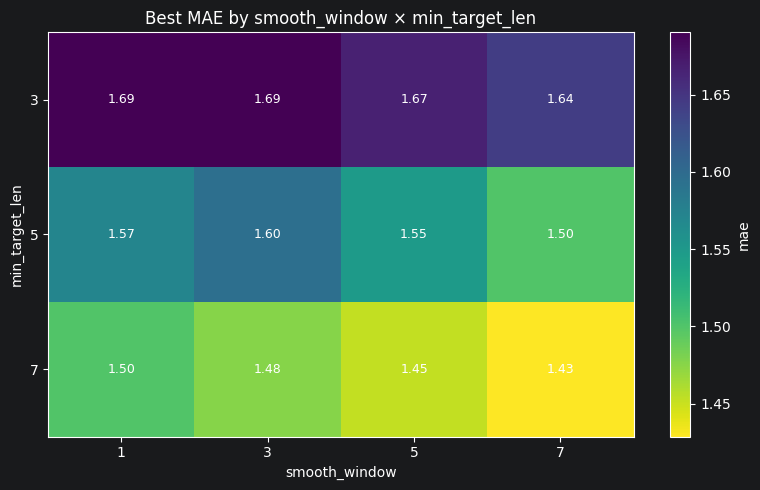

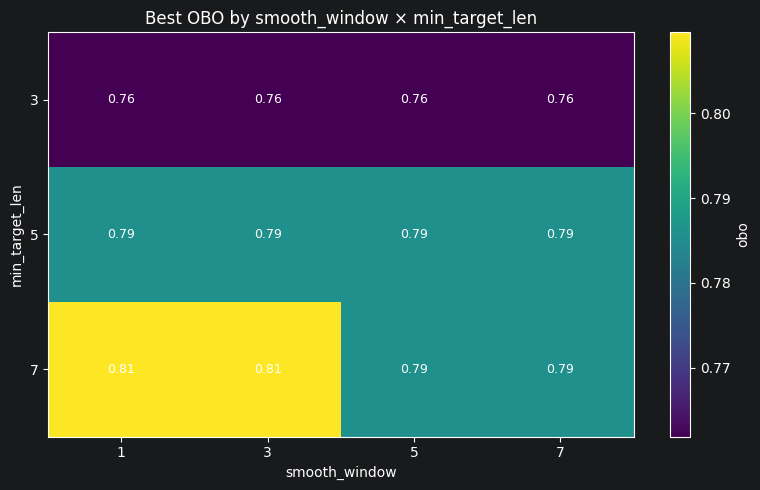

In [10]:
def plot_grid_heatmap(
    grid_df: pd.DataFrame,
    metric: str = "mae",
    require_prior: Optional[bool] = None,
    count_on: Optional[str] = None,
    min_rep_gap: Optional[int] = None,
    title: Optional[str] = None,
):
    df = grid_df.copy()
    if require_prior is not None:
        df = df[df["require_prior"] == require_prior]
    if count_on is not None:
        df = df[df["count_on"] == count_on]
    if min_rep_gap is not None:
        df = df[df["min_rep_gap"] == min_rep_gap]
    if df.empty:
        print("No rows after filters")
        return

    agg_func = "min" if metric in {"mae", "bias", "under_rate", "over_rate"} else "max"
    pivot = df.pivot_table(index="min_target_len", columns="smooth_window", values=metric, aggfunc=agg_func)

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis_r" if metric == "mae" else "viridis")
    ax.set_xticks(range(len(pivot.columns)), pivot.columns)
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set_xlabel("smooth_window")
    ax.set_ylabel("min_target_len")
    ax.set_title(title or f"{metric} heatmap")
    fig.colorbar(im, ax=ax, label=metric)

    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            val = pivot.values[r, c]
            if pd.notna(val):
                ax.text(c, r, f"{val:.2f}", ha="center", va="center", color="white", fontsize=9)
    plt.tight_layout()
    plt.show()


plot_grid_heatmap(grid_df, metric="mae", title="Best MAE by smooth_window × min_target_len")
plot_grid_heatmap(grid_df, metric="obo", title="Best OBO by smooth_window × min_target_len")

## 6) Best config 적용 + 영상별 오차


### Best grid config

| videos | MAE ↓ | OBO ↑ | Exact ↑ | Bias | Over-rate | Under-rate | mean phase acc |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 42 | 1.429 | 0.786 | 0.571 | -0.524 | 0.167 | 0.262 | 0.568 |


best phase cfg: PhasePrepConfig(prob_method='raw', ema_alpha=0.35, confidence_min=0.0, margin_min=0.0, hold_low_confidence=True, smooth_window=7, smooth_mode='causal', tie_break='latest')
best count cfg: CountConfig(target_phase='up', prior_phase='down', require_prior=True, prior_must_be_adjacent=False, min_target_len=7, min_prior_len=1, min_rep_gap=0, count_on='min_len_reached', count_terminal_segment=False, target_phase_by_exercise=None, prior_phase_by_exercise=None)


,type,name,T,valid_frames,gt_count,pred_count,error,abs_error,phase_acc_full,events,segments
13,benchpress,stu7_14.mp4,1440,713,29,14,-15,15,0.295139,"[{'count': 1, 'frame': 56, 'raw_count_frame': ...","[(0, 26, 0), (26, 39, 2), (39, 50, 1), (50, 76..."
12,benchpress,stu7_10.mp4,624,305,8,0,-8,8,0.334936,[],"[(0, 382, 0), (382, 392, 2), (392, 404, 0), (4..."
35,squat,stu7_13.mp4,1799,893,11,17,6,6,0.629238,"[{'count': 1, 'frame': 34, 'raw_count_frame': ...","[(0, 18, 0), (18, 22, 2), (22, 28, 1), (28, 54..."
17,benchpress,test153.mp4,300,143,5,0,-5,5,0.203333,[],"[(0, 176, 0), (176, 184, 2), (184, 190, 1), (1..."
15,benchpress,stu9_11.mp4,1798,892,15,19,4,4,0.501112,"[{'count': 1, 'frame': 112, 'raw_count_frame':...","[(0, 22, 0), (22, 26, 2), (26, 42, 0), (42, 52..."
16,benchpress,stu9_6.mp4,299,143,5,1,-4,4,0.518395,"[{'count': 1, 'frame': 96, 'raw_count_frame': ...","[(0, 62, 0), (62, 68, 1), (68, 90, 0), (90, 11..."
41,squat,train3948.mp4,300,143,0,4,4,4,0.260000,"[{'count': 1, 'frame': 48, 'raw_count_frame': ...","[(0, 18, 0), (18, 28, 1), (28, 34, 2), (34, 42..."
18,benchpress,train151.mp4,86,36,3,0,-3,3,0.476744,[],"[(0, 18, 0), (18, 24, 2), (24, 86, 0)]"
11,benchpress,stu10_9.mp4,650,318,5,7,2,2,0.558462,"[{'count': 1, 'frame': 106, 'raw_count_frame':...","[(0, 52, 0), (52, 58, 1), (58, 66, 0), (66, 72..."
1,benchpress,bench press_14.mp4,54,20,1,0,-1,1,0.111111,[],"[(0, 30, 0), (30, 36, 2), (36, 54, 0)]"


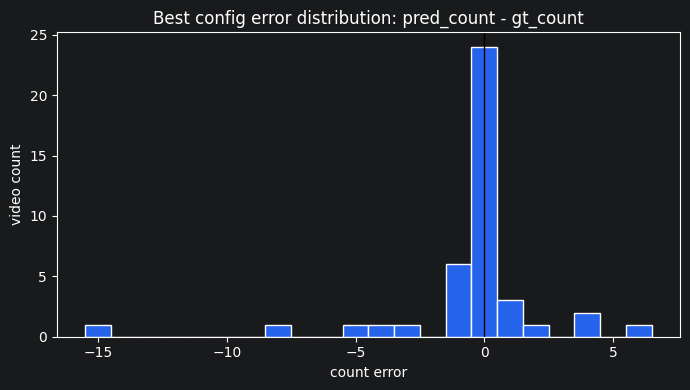

In [11]:
best = grid_df.iloc[0].to_dict()
best_phase_cfg = PhasePrepConfig(
    prob_method=best["prob_method"],
    smooth_window=int(best["smooth_window"]),
    smooth_mode=best["smooth_mode"],
    tie_break=best["tie_break"],
    confidence_min=float(best["confidence_min"]),
    margin_min=float(best["margin_min"]),
)
best_count_cfg = CountConfig(
    target_phase="up",
    prior_phase="down",
    require_prior=bool(best["require_prior"]),
    min_target_len=int(best["min_target_len"]),
    min_prior_len=int(best["min_prior_len"]),
    min_rep_gap=int(best["min_rep_gap"]),
    count_on=best["count_on"],
    count_terminal_segment=False,
)

best_video_df, best_summary = evaluate_count_config(pred_df, labels, best_phase_cfg, best_count_cfg)
show_summary(best_summary, "Best grid config")
print("best phase cfg:", best_phase_cfg)
print("best count cfg:", best_count_cfg)
display(best_video_df.sort_values("abs_error", ascending=False).head(20))

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(best_video_df["error"].min() - 0.5, best_video_df["error"].max() + 1.5, 1)
ax.hist(best_video_df["error"], bins=bins, edgecolor="white", color="#2563eb")
ax.axvline(0, color="black", lw=1)
ax.set_title("Best config error distribution: pred_count - gt_count")
ax.set_xlabel("count error")
ax.set_ylabel("video count")
plt.tight_layout()
plt.show()

## 7) 한 영상 timeline 가시화

기본은 best config에서 count 오차가 가장 큰 영상을 자동 선택합니다.
특정 영상을 보고 싶으면 `SELECT_TYPE`, `SELECT_NAME`을 지정하세요.

In [ ]:
# timeline?? ?? ??? ?? ?????.
# "preset": 4.5 ??? selected_preset_name ?? ??
# "grid_best": 6? ??? grid search 1? ?? ??
TIMELINE_CONFIG_SOURCE = "preset"  # "preset" | "grid_best"

SELECT_TYPE: Optional[str] = None
SELECT_NAME: Optional[str] = None


def get_video_group(pred_df: pd.DataFrame, video_df: pd.DataFrame, select_type=None, select_name=None):
    if select_type is None or select_name is None:
        row = video_df.sort_values("abs_error", ascending=False).iloc[0]
        select_type, select_name = row["type"], row["name"]
    g = pred_df[(pred_df["type"] == select_type) & (pred_df["name"] == select_name)]
    if g.empty:
        raise ValueError(f"video not found: {select_type}/{select_name}")
    return str(select_type), str(select_name), g


def plot_phase_timeline(
    pred_df: pd.DataFrame,
    labels: Mapping[Tuple[str, str], Mapping[str, object]],
    phase_cfg: PhasePrepConfig,
    count_cfg: CountConfig,
    select_type: Optional[str] = None,
    select_name: Optional[str] = None,
    phase_label_scheme: str = PHASE_LABEL_SCHEME_RESOLVED,
):
    video_df, _ = evaluate_count_config(pred_df, labels, phase_cfg, count_cfg, phase_label_scheme=phase_label_scheme)
    exercise, name, g = get_video_group(pred_df, video_df, select_type, select_name)
    raw_seq, probs, valid_idx = reconstruct_full_sequence(g, phase_col="pred_phase_raw")
    tuned_seq = prepare_phase_sequence(raw_seq, probs, phase_cfg, exercise=exercise)
    result = count_phase_sequence(tuned_seq, exercise=exercise, cfg=count_cfg)

    label = labels.get((exercise, name), {})
    reps = label.get("reps", []) if isinstance(label, Mapping) else []
    gt_count = int(label.get("rep_count", len(reps))) if isinstance(label, Mapping) else np.nan
    gt_seq = make_gt_phase(len(tuned_seq), reps, exercise, phase_label_scheme) if reps else np.zeros_like(tuned_seq)

    rows = [("GT", gt_seq), ("raw", raw_seq), ("tuned", tuned_seq)]
    fig, axes = plt.subplots(len(rows), 1, figsize=(16, 4.8), sharex=True)
    if len(rows) == 1:
        axes = [axes]

    for ax, (label_name, seq) in zip(axes, rows):
        ax.imshow(seq[np.newaxis, :], aspect="auto", interpolation="nearest", cmap=PHASE_CMAP, vmin=0, vmax=2)
        ax.set_yticks([])
        ax.set_ylabel(label_name, rotation=0, labelpad=35, va="center")
        for s, b, f in reps:
            ax.axvline(s, color="#111827", lw=0.7, alpha=0.35)
            ax.axvline(b, color="#f59e0b", lw=0.9, alpha=0.55)
            ax.axvline(f, color="#111827", lw=0.7, alpha=0.35)
        if label_name == "tuned":
            for ev in result["events"]:
                ax.axvline(ev["frame"], color="#ef4444", lw=1.8, alpha=0.95)
                ax.text(ev["frame"], 0.9, str(ev["count"]), color="#ef4444", fontsize=9, rotation=90, va="bottom")

    axes[-1].set_xlabel("frame")
    fig.suptitle(
        f"{exercise}/{name} | gt={gt_count}, pred={result['count']}, error={result['count'] - gt_count} | "
        f"phase={phase_cfg} | count={count_cfg}",
        fontsize=10,
    )
    handles = [plt.Line2D([0], [0], color=c, lw=8) for c in PHASE_COLORS]
    fig.legend(handles, PHASE_NAMES, loc="upper right")
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    display(Markdown(f"### Selected video: `{exercise}/{name}`"))
    display(pd.DataFrame(result["events"]))


if TIMELINE_CONFIG_SOURCE == "preset" and "selected_phase_cfg" in globals() and "selected_count_cfg" in globals():
    timeline_phase_cfg = selected_phase_cfg
    timeline_count_cfg = selected_count_cfg
    timeline_config_name = f"preset:{selected_preset_name}"
elif TIMELINE_CONFIG_SOURCE == "grid_best":
    timeline_phase_cfg = best_phase_cfg
    timeline_count_cfg = best_count_cfg
    timeline_config_name = "grid_best"
else:
    raise ValueError("TIMELINE_CONFIG_SOURCE must be 'preset' or 'grid_best'")

print("timeline_config:", timeline_config_name)
plot_phase_timeline(pred_df, labels, timeline_phase_cfg, timeline_count_cfg, SELECT_TYPE, SELECT_NAME)

## 8) 고급: confidence / EMA 기반 phase 안정화 실험

`prob_method='ema'`는 phase probability를 EMA로 먼저 부드럽게 만든 뒤 phase id를 다시 뽑습니다.
`confidence_min`, `margin_min`은 애매한 frame에서 이전 phase를 유지하는 필터입니다.

,videos,mae,obo,exact,bias,over_rate,under_rate,phase_acc_full,prob_method,confidence_min,margin_min,smooth_window,smooth_mode,tie_break,min_target_len,require_prior,min_prior_len,min_rep_gap,count_on
0,42.0,1.500000,0.785714,0.500000,-0.690476,0.119048,0.380952,0.586879,ema,0.5,0.00,1,causal,latest,5,True,3,0,segment_end
1,42.0,1.500000,0.785714,0.500000,-0.690476,0.119048,0.380952,0.586879,ema,0.5,0.00,1,causal,latest,5,True,3,8,segment_end
2,42.0,1.500000,0.785714,0.500000,-0.690476,0.119048,0.380952,0.572493,ema,0.5,0.00,3,causal,latest,5,True,3,0,segment_end
3,42.0,1.500000,0.785714,0.500000,-0.690476,0.119048,0.380952,0.572493,ema,0.5,0.00,3,causal,latest,5,True,3,8,segment_end
4,42.0,1.523810,0.785714,0.452381,-0.666667,0.142857,0.404762,0.579165,ema,0.5,0.15,1,causal,latest,5,True,3,0,segment_end
5,42.0,1.523810,0.785714,0.452381,-0.666667,0.142857,0.404762,0.579165,ema,0.5,0.15,1,causal,latest,5,True,3,8,segment_end
6,42.0,1.523810,0.785714,0.452381,-0.666667,0.142857,0.404762,0.563295,ema,0.5,0.15,3,causal,latest,5,True,3,0,segment_end
7,42.0,1.523810,0.785714,0.452381,-0.666667,0.142857,0.404762,0.563295,ema,0.5,0.15,3,causal,latest,5,True,3,8,segment_end
8,42.0,1.523810,0.761905,0.476190,-0.571429,0.142857,0.380952,0.586879,ema,0.5,0.00,1,causal,latest,5,True,1,0,segment_end
9,42.0,1.523810,0.761905,0.476190,-0.571429,0.142857,0.380952,0.586879,ema,0.5,0.00,1,causal,latest,5,True,1,8,segment_end


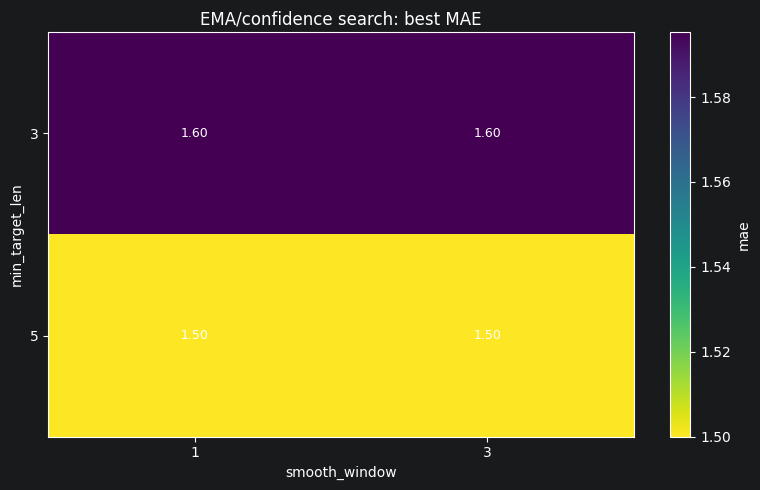

In [13]:
ema_grid_df = run_grid_search(
    pred_df,
    labels,
    # ?? grid? ??? ??. confidence/margin ??? ?? ???? ? ????.
    smooth_windows=(1, 3),
    min_target_lens=(3, 5),
    require_priors=(False, True),
    min_prior_lens=(1, 3),
    min_rep_gaps=(0, 8),
    count_ons=("segment_end",),
    smooth_mode="causal",
    tie_break="latest",
    prob_methods=("raw", "ema"),
    confidence_mins=(0.0, 0.50),
    margin_mins=(0.0, 0.15),
)

display(ema_grid_df.head(20))
plot_grid_heatmap(ema_grid_df, metric="mae", title="EMA/confidence search: best MAE")

## 9) 종목별 target/prior phase override 실험

deadlift 같은 종목에서 `up` count가 맞지 않으면 종목별 target phase를 바꿔볼 수 있습니다.
아래 예시는 deadlift만 `down`을 count target으로 바꿉니다.

In [14]:
per_ex_count_cfg = replace(
    best_count_cfg,
    target_phase_by_exercise={"squat": "up", "benchpress": "up", "deadlift": "down"},
    prior_phase_by_exercise={"squat": "down", "benchpress": "down", "deadlift": "up"},
)
per_ex_video_df, per_ex_summary = evaluate_count_config(pred_df, labels, best_phase_cfg, per_ex_count_cfg)
show_summary(per_ex_summary, "Per-exercise target override")

display(
    pd.concat(
        {
            "best_common": best_video_df.groupby("type")["abs_error"].mean(),
            "per_ex_override": per_ex_video_df.groupby("type")["abs_error"].mean(),
        },
        axis=1,
    )
)


### Per-exercise target override

| videos | MAE ↓ | OBO ↑ | Exact ↑ | Bias | Over-rate | Under-rate | mean phase acc |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 42 | 1.476 | 0.762 | 0.571 | -0.524 | 0.190 | 0.238 | 0.568 |


,best_common,per_ex_override
type,,
benchpress,2.315789,2.315789
deadlift,0.600000,1.000000
squat,0.722222,0.722222


## 10) Phase F1/Acc ?? ?? artifact ?? ?? ?? ??

`phase_experiments/**/phase_diagnostics.csv`? ???? full-size artifact ? phase macro F1 / accuracy? ?? `raw_phase_predictions.csv`? ???, ?? `EXPERIMENT_PRESETS` count rule? ?? ??? ?????.

- selection ??: `raw_phase_macro_f1` ??, `raw_phase_acc` ??
- count ??: ? artifact? `pred_phase_raw`
- label scheme: path? `bar_direction`? ??? `bar_direction`, ??? `as_labeled`


In [ ]:
MULTI_MODEL_TOP_N = 8
MULTI_MODEL_MIN_N = 10_000
MULTI_MODEL_PRESETS: Optional[Sequence[str]] = None  # None?? EXPERIMENT_PRESETS ??. ?: ["exercise_specific_balanced", "strong_smoothing"]


def infer_phase_label_scheme_from_path(path: Path | str) -> str:
    text = str(path).replace("\\", "/").lower()
    return "bar_direction" if "bar_direction" in text or "label_bar_direction" in text else "as_labeled"


def short_artifact_name(path: Path | str, max_len: int = 96) -> str:
    p = Path(path)
    parts = p.parts
    if len(parts) >= 2:
        name = parts[-2]
    else:
        name = p.stem
    return name if len(name) <= max_len else name[: max_len - 3] + "..."


def collect_phase_artifacts(root: Path = REPO, min_n: int = MULTI_MODEL_MIN_N) -> pd.DataFrame:
    rows = []
    for diag_path in root.glob("phase_experiments/**/phase_diagnostics.csv"):
        pred_path = diag_path.with_name("raw_phase_predictions.csv")
        if not pred_path.exists():
            continue
        try:
            diag_df = pd.read_csv(diag_path)
        except Exception as exc:
            print("skip unreadable diagnostics:", diag_path, exc)
            continue
        raw = diag_df[diag_df["mode"] == "raw"]
        offline = diag_df[diag_df["mode"] == "offline_smooth"]
        if raw.empty:
            continue
        raw_row = raw.iloc[0]
        offline_row = offline.iloc[0] if not offline.empty else raw_row
        raw_n = int(raw_row.get("n", 0))
        if raw_n < min_n:
            continue
        raw_acc = float(raw_row["phase_acc"])
        raw_f1 = float(raw_row["phase_macro_f1"])
        rows.append(
            {
                "artifact_name": short_artifact_name(pred_path),
                "pred_path": str(pred_path),
                "diag_path": str(diag_path),
                "phase_label_scheme": infer_phase_label_scheme_from_path(pred_path),
                "raw_n": raw_n,
                "raw_phase_acc": raw_acc,
                "raw_phase_macro_f1": raw_f1,
                "offline_phase_acc": float(offline_row["phase_acc"]),
                "offline_phase_macro_f1": float(offline_row["phase_macro_f1"]),
                "selection_score": (raw_acc + raw_f1) / 2.0,
                "mtime": pred_path.stat().st_mtime,
            }
        )
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    return df.sort_values(["raw_phase_macro_f1", "raw_phase_acc", "mtime"], ascending=[False, False, False]).reset_index(drop=True)


def selected_multi_model_presets() -> List[Mapping[str, object]]:
    if MULTI_MODEL_PRESETS is None:
        return list(EXPERIMENT_PRESETS)
    wanted = set(MULTI_MODEL_PRESETS)
    return [p for p in EXPERIMENT_PRESETS if str(p["name"]) in wanted]


def run_top_phase_model_count_eval(
    artifact_df: pd.DataFrame,
    labels: Mapping[Tuple[str, str], Mapping[str, object]],
    top_n: int = MULTI_MODEL_TOP_N,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[Tuple[str, str], pd.DataFrame]]:
    presets = selected_multi_model_presets()
    selected_artifacts = artifact_df.head(top_n).copy()
    summary_rows = []
    video_results: Dict[Tuple[str, str], pd.DataFrame] = {}

    for artifact_rank, artifact in selected_artifacts.iterrows():
        artifact_name = str(artifact["artifact_name"])
        pred_path = Path(str(artifact["pred_path"]))
        scheme = str(artifact["phase_label_scheme"])
        print(f"[{artifact_rank + 1}/{len(selected_artifacts)}]", artifact_name)
        artifact_pred_df = load_predictions(pred_path)
        if MAX_VIDEOS is not None:
            keep = artifact_pred_df[["type", "name"]].drop_duplicates().head(MAX_VIDEOS)
            artifact_pred_df = artifact_pred_df.merge(keep, on=["type", "name"], how="inner")

        for preset in presets:
            preset_name = str(preset["name"])
            phase_cfg_i = _phase_cfg_from_preset(preset)
            count_cfg_i = _count_cfg_from_preset(preset)
            video_df_i, summary_i = evaluate_count_config(
                artifact_pred_df,
                labels,
                phase_cfg_i,
                count_cfg_i,
                phase_label_scheme=scheme,
            )
            video_results[(artifact_name, preset_name)] = video_df_i
            summary_rows.append(
                {
                    "artifact_rank": int(artifact_rank + 1),
                    "artifact_name": artifact_name,
                    "preset": preset_name,
                    "phase_label_scheme": scheme,
                    "pred_path": str(pred_path),
                    "raw_phase_acc": float(artifact["raw_phase_acc"]),
                    "raw_phase_macro_f1": float(artifact["raw_phase_macro_f1"]),
                    "offline_phase_acc": float(artifact["offline_phase_acc"]),
                    "offline_phase_macro_f1": float(artifact["offline_phase_macro_f1"]),
                    **summary_i,
                }
            )

    summary_df = pd.DataFrame(summary_rows).sort_values(
        ["mae", "obo", "exact", "raw_phase_macro_f1"],
        ascending=[True, False, False, False],
    ).reset_index(drop=True)
    return selected_artifacts, summary_df, video_results


phase_artifact_rank_df = collect_phase_artifacts(REPO, min_n=MULTI_MODEL_MIN_N)
display(phase_artifact_rank_df.head(20)[[
    "artifact_name",
    "phase_label_scheme",
    "raw_n",
    "raw_phase_acc",
    "raw_phase_macro_f1",
    "offline_phase_acc",
    "offline_phase_macro_f1",
    "pred_path",
]])

selected_phase_artifacts_df, multi_model_preset_compare_df, multi_model_video_results = run_top_phase_model_count_eval(
    phase_artifact_rank_df,
    labels,
    top_n=MULTI_MODEL_TOP_N,
)

best_preset_per_artifact_df = (
    multi_model_preset_compare_df
    .sort_values(["artifact_rank", "mae", "obo", "exact"], ascending=[True, True, False, False])
    .groupby("artifact_name", as_index=False)
    .head(1)
    .sort_values(["mae", "obo", "exact"], ascending=[True, False, False])
    .reset_index(drop=True)
)

print("selected top phase artifacts:", len(selected_phase_artifacts_df))
display(best_preset_per_artifact_df[[
    "artifact_name",
    "preset",
    "phase_label_scheme",
    "raw_phase_acc",
    "raw_phase_macro_f1",
    "mae",
    "obo",
    "exact",
    "bias",
    "over_rate",
    "under_rate",
]])

print("overall best model/preset combinations")
display(multi_model_preset_compare_df[[
    "artifact_name",
    "preset",
    "phase_label_scheme",
    "raw_phase_acc",
    "raw_phase_macro_f1",
    "mae",
    "obo",
    "exact",
    "bias",
    "over_rate",
    "under_rate",
]].head(25))

# phase metric? count metric ?? ???
corr_cols = ["raw_phase_acc", "raw_phase_macro_f1", "mae", "obo", "exact", "bias"]
if len(multi_model_preset_compare_df) > 1:
    display(multi_model_preset_compare_df[corr_cols].corr(numeric_only=True))


## 11) ?? ??


In [ ]:
OUT_DIR = REPO / "phase_experiments" / "count_tuning_notebook"
OUT_DIR.mkdir(parents=True, exist_ok=True)

grid_path = OUT_DIR / "count_tuning_grid.csv"
best_video_path = OUT_DIR / "count_tuning_best_video_results.csv"
ema_grid_path = OUT_DIR / "count_tuning_ema_grid.csv"
preset_compare_path = OUT_DIR / "count_tuning_preset_compare.csv"
selected_preset_video_path = OUT_DIR / f"count_tuning_preset_{selected_preset_name}_video_results.csv"
all_preset_video_path = OUT_DIR / "count_tuning_preset_video_results_all.csv"
phase_artifact_rank_path = OUT_DIR / "count_tuning_phase_artifact_rank.csv"
multi_model_compare_path = OUT_DIR / "count_tuning_top_phase_models_preset_compare.csv"
best_preset_per_artifact_path = OUT_DIR / "count_tuning_top_phase_models_best_per_artifact.csv"
selected_phase_artifacts_path = OUT_DIR / "count_tuning_selected_phase_artifacts.csv"

grid_df.to_csv(grid_path, index=False, encoding="utf-8-sig")
best_video_df.drop(columns=["events", "segments"], errors="ignore").to_csv(best_video_path, index=False, encoding="utf-8-sig")
ema_grid_df.to_csv(ema_grid_path, index=False, encoding="utf-8-sig")

preset_compare_df.to_csv(preset_compare_path, index=False, encoding="utf-8-sig")
selected_video_df.drop(columns=["events", "segments"], errors="ignore").to_csv(
    selected_preset_video_path,
    index=False,
    encoding="utf-8-sig",
)
all_preset_video_df = pd.concat(
    [
        df.drop(columns=["events", "segments"], errors="ignore").assign(preset=name)
        for name, df in preset_video_results.items()
    ],
    ignore_index=True,
)
all_preset_video_df.to_csv(all_preset_video_path, index=False, encoding="utf-8-sig")

if "phase_artifact_rank_df" in globals():
    phase_artifact_rank_df.to_csv(phase_artifact_rank_path, index=False, encoding="utf-8-sig")
if "selected_phase_artifacts_df" in globals():
    selected_phase_artifacts_df.to_csv(selected_phase_artifacts_path, index=False, encoding="utf-8-sig")
if "multi_model_preset_compare_df" in globals():
    multi_model_preset_compare_df.to_csv(multi_model_compare_path, index=False, encoding="utf-8-sig")
if "best_preset_per_artifact_df" in globals():
    best_preset_per_artifact_df.to_csv(best_preset_per_artifact_path, index=False, encoding="utf-8-sig")

print("saved:")
for p in [
    grid_path,
    best_video_path,
    ema_grid_path,
    preset_compare_path,
    selected_preset_video_path,
    all_preset_video_path,
    phase_artifact_rank_path,
    selected_phase_artifacts_path,
    multi_model_compare_path,
    best_preset_per_artifact_path,
]:
    if p.exists():
        print("-", p)
